In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import joblib

In [4]:
df = pd.read_csv(
    "../data/events_features.csv"
)

print(df.shape)

df.head()

(8173, 59)


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,year,duration_hours,cause_score,closure_score,priority_score,impact_score,risk_level,weekend,lat_grid,lon_grid
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,2024.0,NaN,2.0,0,5.0,7.0,Medium,0,13.04,77.52
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,2024.0,NaN,2.0,0,5.0,7.0,Medium,0,12.92,77.65
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,2023.0,NaN,3.0,0,1.0,4.0,Low,1,12.96,77.59
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,2024.0,NaN,5.0,5,1.0,11.0,High,0,13.01,77.58
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,2024.0,NaN,2.0,0,1.0,3.0,Low,0,12.95,77.59


In [5]:
df["risk_level"].value_counts()

risk_level
Medium      4892
Low         2182
High         966
Critical     133
Name: count, dtype: int64

In [6]:
features = [
    "event_cause",
    "requires_road_closure",
    "hour",
    "day_of_week",
    "month",
    "weekend",
    "zone"
]

target = "risk_level"

In [7]:
X = df[features].copy()

y = df[target]

In [8]:
X["zone"] = X["zone"].fillna(
    "Unknown"
)

In [9]:
label_encoders = {}

categorical_cols = [
    "event_cause",
    "zone"
]

for col in categorical_cols:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = le

In [10]:
target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(
    y
)

In [11]:
target_encoder.classes_

array(['Critical', 'High', 'Low', 'Medium'], dtype=object)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [13]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=12, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [14]:
preds = model.predict(X_test)

In [15]:
acc = accuracy_score(
    y_test,
    preds
)

print(
    f"Accuracy: {acc:.4f}"
)

Accuracy: 0.6917


In [16]:
print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.64      0.67      0.65        27
           1       0.71      0.75      0.73       193
           2       0.68      0.17      0.28       436
           3       0.69      0.91      0.79       979

    accuracy                           0.69      1635
   macro avg       0.68      0.62      0.61      1635
weighted avg       0.69      0.69      0.64      1635



In [17]:
cm = confusion_matrix(
    y_test,
    preds
)

print(cm)

[[ 18   9   0   0]
 [  9 144   0  40]
 [  0   0  76 360]
 [  1  50  35 893]]


In [18]:
import matplotlib.pyplot as plt

importance_df = pd.DataFrame(
    {
        "feature": X.columns,
        "importance": model.feature_importances_
    }
)

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df

,feature,importance
0,event_cause,0.357296
2,hour,0.164585
1,requires_road_closure,0.164550
6,zone,0.134317
3,day_of_week,0.087011
4,month,0.079547
5,weekend,0.012693


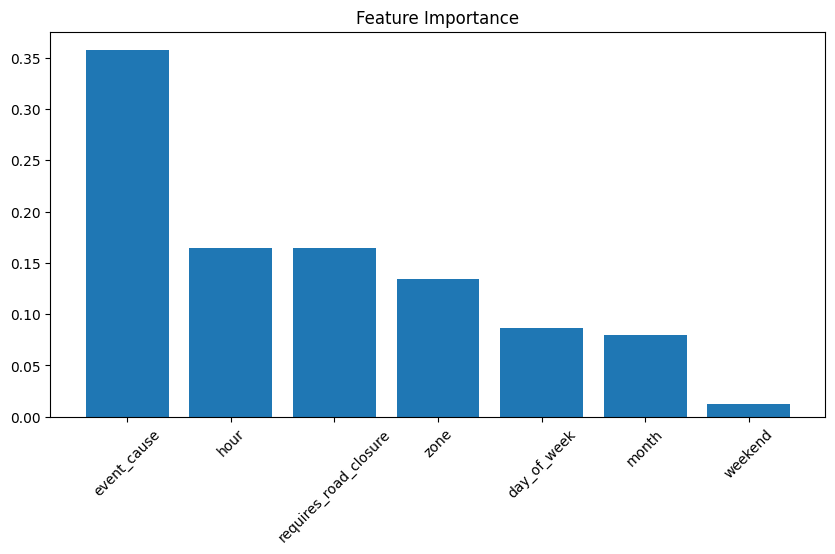

In [19]:
plt.figure(figsize=(10,5))

plt.bar(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xticks(rotation=45)

plt.title(
    "Feature Importance"
)

plt.show()

In [20]:
joblib.dump(
    model,
    "../backend/ml/saved_models/risk_model.pkl"
)

['../backend/ml/saved_models/risk_model.pkl']

In [21]:
joblib.dump(
    target_encoder,
    "../backend/ml/encoders/target_encoder.pkl"
)

['../backend/ml/encoders/target_encoder.pkl']

In [22]:
joblib.dump(
    label_encoders,
    "../backend/ml/encoders/feature_encoders.pkl"
)

['../backend/ml/encoders/feature_encoders.pkl']

In [23]:
probs = model.predict_proba(X_test)

probs[:5]

array([[0.        , 0.00191256, 0.31313576, 0.68495167],
       [0.00358025, 0.95028809, 0.        , 0.04613166],
       [0.        , 0.00185536, 0.30249728, 0.69564736],
       [0.        , 0.02136091, 0.15720575, 0.82143334],
       [0.        , 0.0016646 , 0.33902687, 0.65930853]])

In [24]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

probability = model.predict_proba(sample)

print("Prediction:", prediction)

print("Confidence:", probability.max())

Prediction: [3]
Confidence: 0.6849516730747303


In [25]:
importance_df.to_csv(
    "../docs/feature_importance.csv",
    index=False
)

In [26]:
for col in [
    "event_type",
    "corridor",
    "junction",
    "zone",
]:
    print("\n", col)
    print(df[col].nunique())
    print(df[col].value_counts().head())


 event_type
2
event_type
unplanned    7706
planned       467
Name: count, dtype: int64

 corridor
22
corridor
Non-corridor      3124
Mysore Road        743
Bellary Road 1     610
Tumkur Road        458
Bellary Road 2     379
Name: count, dtype: int64

 junction
294
junction
MekhriCircle             64
AyyappaTempleJunc        49
SatteliteBusStandJunc    43
YeshwanthpuraCircle      38
YelhankaCircle           34
Name: count, dtype: int64

 zone
10
zone
Central Zone 2    623
West Zone 1       433
North Zone 2      413
West Zone 2       358
South Zone 2      354
Name: count, dtype: int64


In [27]:
print(df["latitude"].describe())
print(df["longitude"].describe())

count    8173.000000
mean       12.987076
std         0.060109
min        12.801041
25%        12.951635
50%        12.982847
75%        13.026867
max        13.267510
Name: latitude, dtype: float64
count    8173.000000
mean       77.596034
std         0.061193
min        77.308731
25%        77.556747
50%        77.589460
75%        77.625853
max        77.769403
Name: longitude, dtype: float64
